# Issue 6d: ESMFold2 Self-Confidence and FoldSeek.

> **Author:** Alexander Leonardos\
> **Date Started:** July 29th, 2026\
> **Date Finished:** August 5th, 2026 NOTE: This is just the validation that the graphs show up properly using test sets, NOT that the actual analysis is fully done.\
> **Input:** `s3://petadex-protein-structures/esmfold2-centroids/`\
> **Output:** Graph analysis.

---

## Objective

The goal of this notebook is to graph the following ESMFold2 sub-experiment:

### Group D: Metrics for the final distribution from the best model

- [x] **Da**. *Quality for best model (structural feasibility)*: Distribution of mean-pLDDT or pTM and its corresponding fraction above 70 or 80. (Indicative of usable structures). Use these results to conclude about the *use of the generated structures*.

- [x] **Db**. *Novelty of new structures (novelty)*: Distribution of FoldSeek best-hit similarity score

  - (searches through PDB or AFDB quickly and finds the closest structure and a similarity score for that structure), and its corresponding fraction above a threshold.

  - Make the other dimension confidence to isolate for confidently novel structures - most interesting.

- [ ] ***FOR NOW: This was supposed to just use the better model between MSA addition and base, but I can just make the graphs using the base for now.***

## Note

Unlike groups B and C, **Da and Db are single-run figures** — they need no second run and no ground
truth, just one prediction prefix. So the two-set stand-in used in 6b and 6c does not apply here; one
prefix is all they consume.

Until the full centroid fold lands, that prefix is experiment A's
`s3://petadex-protein-structures/esmfold2_paramsweep/s68_l10/` — **68 sampling steps / 10 loops, the
config 6a concluded on**, so the numbers below are the ones the real run will produce, just over 121
ORFs instead of the full centroid set. Point `S3_RUN` at the centroids prefix when it exists;
nothing else in the notebook changes.

**One caveat that applies to Db specifically:** those 121 ORFs were selected in 6a *because they have
a PDB entry*, which makes them a poor stand-in for a novelty figure and an excellent **calibration
set** — every one is a known homolog, so anything landing in the "novel" corner is a false positive
that can be measured. §4c reads the figure on that basis.

## 0. Deps

In [1]:
# Install the required packages with the versions used for the analysis.
import sys, subprocess

PACKAGES = [
    # this notebook (figures) + conf_metrics.py (reading the confidence scalars)
    "numpy==2.4.6",
    "matplotlib==3.11.1",
    "boto3==1.43.56",
    "botocore==1.43.56",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PACKAGES], check=True)
print("installed:", ", ".join(PACKAGES))

installed: numpy==2.4.6, matplotlib==3.11.1, boto3==1.43.56, botocore==1.43.56


## 1. Config + paths

One run in, one figure out. `S3_RUN` is the only thing to change when the real centroid folds land.

In [2]:
from pathlib import Path

# --- the run being characterised -------------------------------------------------------------------
S3_RUN = "s3://petadex-protein-structures/esmfold2_paramsweep/s68_l10/"   # STAND-IN (68 steps/10 loops,
                                                                          # the config 6a chose)
# S3_RUN = "s3://petadex-protein-structures/esmfold2-centroids/"          # <- the real run, when it exists
LABEL  = "s68_l10"

# locate repo root (dir containing resources/) from wherever the kernel started
REPO = Path.cwd()
while not (REPO / "resources").exists() and REPO != REPO.parent:
    REPO = REPO.parent
RES  = REPO / "resources" / "260729_issue6d_finalmetrics"
CONF = RES / "conf_metrics.py"
OUT_DA = RES / f"conf_{LABEL}"       # ledger + aggregates land here

assert CONF.exists(), f"conf_metrics.py not found: {CONF}"
print("repo:", REPO)
print("run :", S3_RUN)
print("out :", OUT_DA)

repo: c:\Users\27leo\VSCode\igem-toronto
run : s3://petadex-protein-structures/esmfold2_paramsweep/s68_l10/
out : c:\Users\27leo\VSCode\igem-toronto\resources\260729_issue6d_finalmetrics\conf_s68_l10


In [ ]:
# The predictions bucket is PRIVATE -- conf_metrics.py needs signed creds to read from it.
# Run these in PowerShell/WSL first (the same temp STS keys used for the VM uploads); a 403 or
# ExpiredToken in the next cell means these need refreshing.
"""
aws configure set aws_access_key_id <your-access-key-id>
aws configure set aws_secret_access_key <your-secret-access-key>
aws configure set aws_session_token <your-session-token>      # if using temporary credentials
aws configure set default.region us-east-1
"""

# Da

**Da.** *Quality for the best model* — the distribution of mean pLDDT and pTM over every folded ORF,
and the fraction above 70 / 80.

### What is being measured, and what it licenses

pLDDT and pTM are the model's **own confidence**, not accuracy. Da is therefore a statement about
**usability**: how much of the generated set is worth passing downstream (Foldseek, featurisation for
the activity predictor, docking), not a claim that those structures are correct. Treating confidence
as a quality proxy is the standard move when ground truth does not exist at scale — which is exactly
the premise recorded at the top of `experiment_descriptions.md`, since the ESMAtlas is new enough
that almost nothing in it has a post-training-cutoff crystal structure. Accuracy against real
structures is group C, on the ~121 ORFs where that is even possible.

The conventional AlphaFold reading of the pLDDT bands carries over: **> 90** ≈ backbone *and*
sidechains reliable, **70–90** ≈ backbone reliable, **50–70** ≈ low confidence / treat with caution,
**< 50** ≈ often disordered rather than wrong. So "fraction above 70" is really "fraction with a
trustworthy backbone", which is the bar most downstream structural work needs.

### Where the numbers come from — `metrics/*.json`, not `tracker.csv`

Both carry the same scalars, and the tracker is one small file, so it looks like the cheap way in.
It is not the trustworthy one at scale:

- the full centroid fold is **sharded across a fleet**, and each worker mirrors its *own*
  `tracker.shardKofN.csv` — "the ledger" is really N files that have to be found and unioned;
- each mirror happens on a **~300 s interval** (`MIRROR_EVERY_S`), so a tracker read mid-run is stale
  by construction, and a replaced spot instance can come back with a ledger *behind* the objects it
  already uploaded.

A `metrics/<id>.json` object exists **iff** that fold finished and uploaded, so the listing *is* the
set of structures we have — which is the population Da is a statement about.

### Why that costs almost nothing

The rich record is dominated by `pae`, which is **L × L** — a 600 aa ORF's metrics JSON is ~2 MB of
text, so GETting them whole at 630k would move ~600 GB. But the scalars are written *before*
`per_residue_plddt` and `pae`, so a **Range-GET of the first 4 KB** has all of them:

| | whole objects | 4 KB heads |
|---|---|---|
| bytes moved (630k) | ~600 GB | ~2.5 GB |
| GET requests | 630k (~$0.25) | 630k (~$0.25) |

That makes the run **request-latency-bound rather than bandwidth-bound**, which is the regime
`--workers` scales nearly linearly in. If the layout ever changes, an object whose head lacks a
required scalar is automatically re-fetched whole and the count is reported — so a silent regression
shows up as a number rather than as bad data.

### 2a. Read the confidence scalars

Streams the heads of `metrics/*.json` and writes `conf.tsv` (one row per ORF) + `aggregates.json`
(the figure input) into `OUT_DA`.

Resumable: re-running only reads what is missing from the ledger, so this is safe to run mid-fold —
ORFs not yet uploaded simply are not in the listing yet and get picked up on the next pass.

In [3]:
import subprocess, sys, time

def read_conf(run=S3_RUN, out=OUT_DA, label=LABEL, workers=32, extra=()):
    """Run conf_metrics.py over one prediction prefix. Resumable -- re-running reads only what is
    missing from the ledger."""
    cmd = [sys.executable, str(CONF), "--run", run, "--label", label,
           "--out", str(out), "--workers", str(workers), *extra]
    print(" ".join(cmd[1:]), "\n")
    t0 = time.perf_counter()
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout[-4000:])
    if r.returncode != 0:
        print("!! conf_metrics.py failed\n", r.stderr[-2000:])
        return None
    print(f"[{time.perf_counter()-t0:.1f}s wall]")
    return out

read_conf()

c:\Users\27leo\VSCode\igem-toronto\resources\260729_issue6d_finalmetrics\conf_metrics.py --run s3://petadex-protein-structures/esmfold2_paramsweep/s68_l10/ --label s68_l10 --out c:\Users\27leo\VSCode\igem-toronto\resources\260729_issue6d_finalmetrics\conf_s68_l10 --workers 32 

run   = s68_l10   s3://petadex-protein-structures/esmfold2_paramsweep/s68_l10/
121 folded ORFs (work list from metrics/ listing, 0.7s)

Da  self-confidence  's68_l10'    n_ok=121   (0.8s)

  mean pLDDT
    mean=95.19  sd=2.30  min=87.17  max=98.68
    quantiles: p1=89.50  p5=91.00  p25=93.50  p50=95.00  p75=97.00  p95=98.00  p99=98.50
    fraction at/above:  50=121/121 (100.00%)  60=121/121 (100.00%)  70=121/121 (100.00%)  80=121/121 (100.00%)  90=119/121 (98.35%)

  pTM
    mean=0.9597  sd=0.0348  min=0.8766  max=0.9970
    quantiles: p1=0.8750  p5=0.8800  p25=0.9350  p50=0.9650  p75=0.9850  p95=0.9900  p99=0.9950
    fraction at/above:  0.5=121/121 (100.00%)  0.7=121/121 (100.00%)  0.8=121/121 (100.00%)  0.9=1

WindowsPath('c:/Users/27leo/VSCode/igem-toronto/resources/260729_issue6d_finalmetrics/conf_s68_l10')

### 2b. Figure Da

Six panels, one row per metric — all read from `aggregates.json`, so this cell costs the same at 121
ORFs or 2 million:

1. **histogram** — the shape of the distribution, with the 70 / 80 (and 0.5 / 0.8 for pTM) reference
   lines Da names;
2. **survival curve** — "what fraction is at or above *X*", which is the actual deliverable and the
   thing a histogram cannot be read off precisely. The curve is bin-resolution; the dots on it are
   the **exact** counts, accumulated during the run rather than read off the bins;
3. **vs. the other dimension** — confidence against ORF length (does it collapse near the 2048 aa
   ESMC context limit?) and pLDDT against pTM (do the two confidence measures even agree?).

The pLDDT/pTM split is deliberately **two rows, not one twin-axis panel**: they live on different
scales (0–100 vs 0–1) and a shared axis would fake a comparison that isn't there.

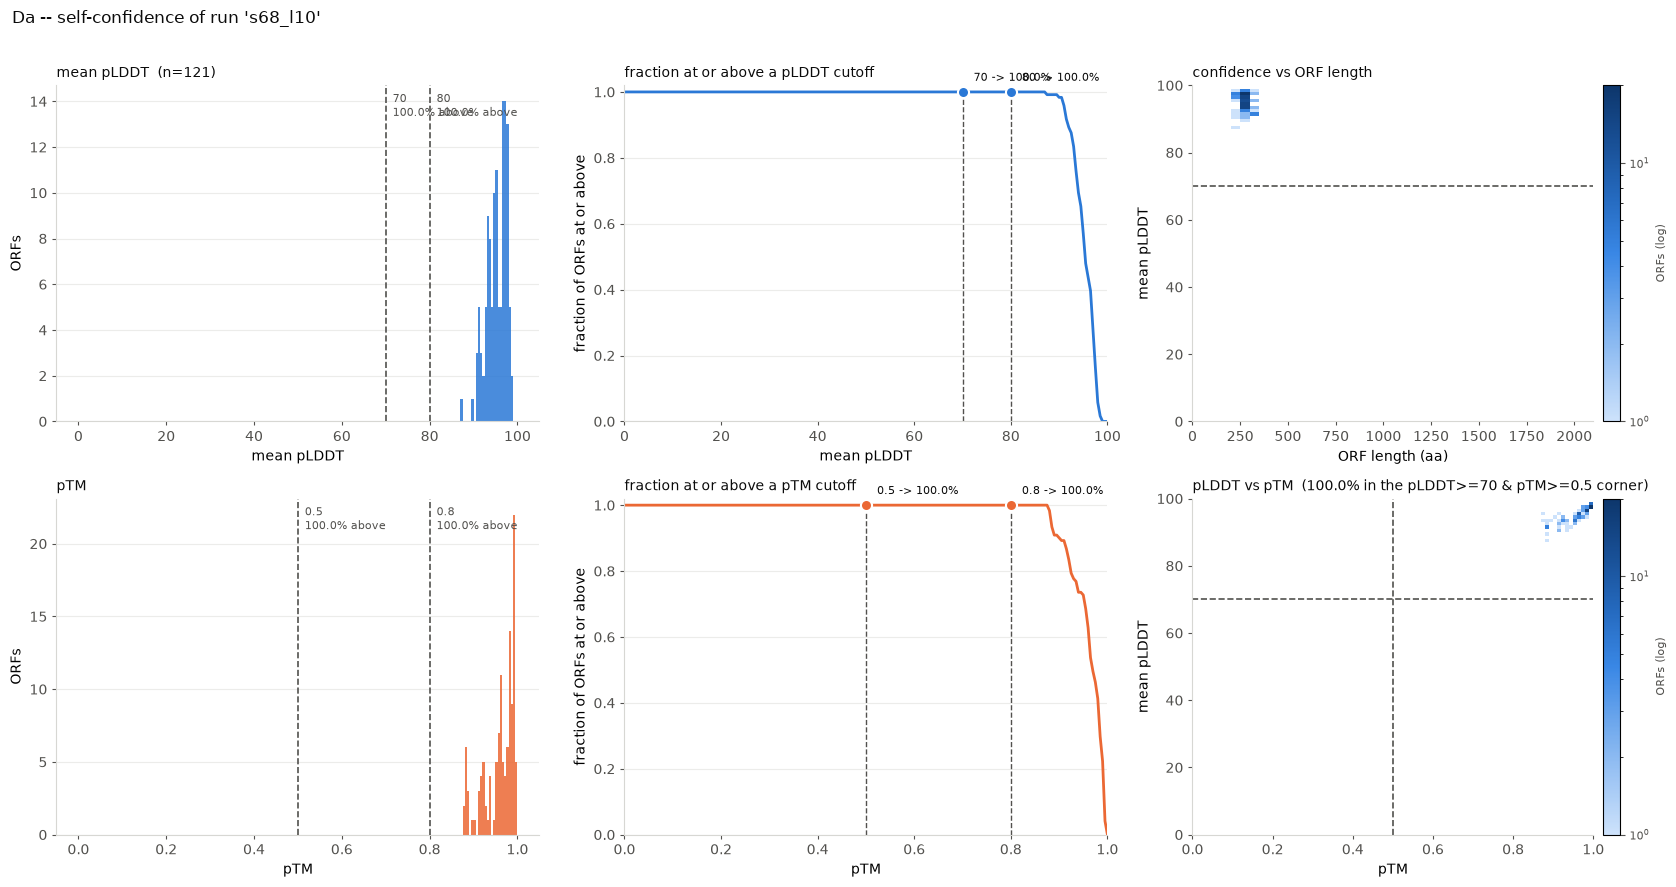

n = 121 structures
  mean pLDDT  mean=95.19  sd=2.30  min=87.17  max=98.68
              >=70: 100.00%   >=80: 100.00%   >=90: 98.35%
  pTM         mean=0.9597  sd=0.0348  min=0.8766  max=0.9970
              >=0.5: 100.00%   >=0.8: 100.00%   >=0.9: 90.08%


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm

# Same reference data-viz palette as 6b, used unchanged: categorical slot 1 (blue) for pLDDT,
# slot 2 (orange) for pTM -- colour follows the entity, so pLDDT stays blue in every panel.
# The 2D panels both encode "number of ORFs", so they share one sequential ramp.
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seqblue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

PLDDT_REFS, PTM_REFS = (70.0, 80.0), (0.5, 0.8)


def load_agg(out_dir):
    """Aggregates for a run: the merged file if shards were merged, else the single-run file."""
    out_dir = Path(out_dir)
    for name in ("aggregates.merged.json", "aggregates.json"):
        if (out_dir / name).exists():
            return json.loads((out_dir / name).read_text())
    raise FileNotFoundError(f"no aggregates*.json in {out_dir} -- run read_conf() first")


def _tidy(ax):
    ax.spines[["top", "right"]].set_visible(False)          # recessive axes
    for s in ax.spines.values():
        s.set_color("#d7d7d3")
    ax.tick_params(colors=MUTED, length=3)
    ax.grid(axis="y", color="#ececea", lw=0.8)
    ax.set_axisbelow(True)


def _hist_panel(ax, counts, spec, color, refs, above, n, xlabel, fmt="{:g}"):
    """Distribution + the reference lines Da names, each direct-labelled with its EXACT fraction."""
    lo, hi, nb = spec
    edges = np.linspace(lo, hi, nb + 1)
    h = np.asarray(counts, dtype=float)
    body = h[:nb].copy()
    body[-1] += h[nb]                                       # overflow cell == exactly `hi`; it belongs
                                                            # at the right edge, not in its own bar
    ax.stairs(body, edges, fill=True, color=color, alpha=.85, lw=0)
    for t in refs:
        ax.axvline(t, color=MUTED, ls="--", lw=1.2, zorder=3)
        ax.annotate(f"{fmt.format(t)}\n{100.0*above[str(t)]/n:.1f}% above", (t, ax.get_ylim()[1]),
                    textcoords="offset points", xytext=(5, -22), fontsize=8, color=MUTED)
    ax.set_xlabel(xlabel); ax.set_ylabel("ORFs")
    _tidy(ax)


def _survival_panel(ax, counts, spec, color, refs, above, n, xlabel, fmt="{:g}"):
    """Fraction at/above x. Curve is bin-resolution; the dots are the exact accumulated counts."""
    lo, hi, nb = spec
    edges = np.linspace(lo, hi, nb + 1)
    h = np.asarray(counts, dtype=float)
    h[nb - 1] += h[nb]
    surv = 1.0 - np.concatenate([[0.0], np.cumsum(h[:nb])]) / n     # at each left edge
    ax.plot(edges, surv, color=color, lw=2, zorder=2)
    for t in refs:
        f = above[str(t)] / n
        ax.plot([t], [f], "o", ms=8, color=color, mec="white", mew=1.5, zorder=4)
        ax.annotate(f"{fmt.format(t)} -> {100*f:.1f}%", (t, f), textcoords="offset points",
                    xytext=(8, 8), fontsize=8, color=INK)
        ax.vlines(t, 0, f, color=MUTED, ls="--", lw=1.0, zorder=1)
    ax.set_ylim(0, 1.02); ax.set_xlim(lo, hi)
    ax.set_xlabel(xlabel); ax.set_ylabel("fraction of ORFs at or above")
    _tidy(ax)


def _density_panel(fig, ax, h2, xedges, yedges, xlabel, ylabel):
    h2 = np.asarray(h2, dtype=float)
    m = np.ma.masked_where(h2 <= 0, h2)
    pc = ax.pcolormesh(xedges, yedges, m, cmap=SEQ_BLUE, norm=LogNorm(vmin=1, vmax=max(2, h2.max())))
    cb = fig.colorbar(pc, ax=ax, pad=0.02)
    cb.set_label("ORFs (log)", color=MUTED, fontsize=8)
    cb.ax.tick_params(colors=MUTED, labelsize=8)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    _tidy(ax); ax.grid(False)


def plot_da(out_dir=OUT_DA, label=LABEL):
    d = load_agg(out_dir)
    n = d["n_ok"]
    if not n:
        print("no ORFs read:", d.get("status"))
        return d
    pl_spec, pt_spec = tuple(d["bins"]["plddt"]), tuple(d["bins"]["ptm"])
    len_spec, jnb = tuple(d["bins"]["len"]), d["bins"]["joint_nb"]

    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    _hist_panel(axes[0, 0], d["hist"]["plddt"], pl_spec, BLUE, PLDDT_REFS, d["plddt_above"], n,
                "mean pLDDT")
    axes[0, 0].set_title(f"mean pLDDT  (n={n:,})", fontsize=10, color=INK, loc="left")
    _survival_panel(axes[0, 1], d["hist"]["plddt"], pl_spec, BLUE, PLDDT_REFS, d["plddt_above"], n,
                    "mean pLDDT")
    axes[0, 1].set_title("fraction at or above a pLDDT cutoff", fontsize=10, color=INK, loc="left")

    # pLDDT vs length: rows are 50 aa length bins, cols are 1-unit pLDDT bins. The final row is the
    # >2100 aa overflow -- nothing can land there (ESMC truncates at 2048), so it is dropped.
    hbl = np.asarray(d["hist"]["plddt_by_len"], dtype=float)[:len_spec[2], :]
    _density_panel(fig, axes[0, 2], hbl.T, np.linspace(*len_spec[:2], len_spec[2] + 1),
                   np.linspace(0, 100, jnb + 1), "ORF length (aa)", "mean pLDDT")
    axes[0, 2].axhline(70, color=MUTED, ls="--", lw=1.2)
    axes[0, 2].set_title("confidence vs ORF length", fontsize=10, color=INK, loc="left")

    _hist_panel(axes[1, 0], d["hist"]["ptm"], pt_spec, ORANGE, PTM_REFS, d["ptm_above"], n,
                "pTM", fmt="{:.1f}")
    axes[1, 0].set_title("pTM", fontsize=10, color=INK, loc="left")
    _survival_panel(axes[1, 1], d["hist"]["ptm"], pt_spec, ORANGE, PTM_REFS, d["ptm_above"], n,
                    "pTM", fmt="{:.1f}")
    axes[1, 1].set_title("fraction at or above a pTM cutoff", fontsize=10, color=INK, loc="left")

    hbp = np.asarray(d["hist"]["plddt_by_ptm"], dtype=float)        # rows pLDDT, cols pTM
    _density_panel(fig, axes[1, 2], hbp, np.linspace(0, 1, jnb + 1), np.linspace(0, 100, jnb + 1),
                   "pTM", "mean pLDDT")
    # 70 and 0.5 fall exactly on bin edges (1-unit pLDDT / 0.01 pTM), so this joint count is EXACT,
    # not bin-resolution -- the one place the 2D panel can be read as a number.
    joint = hbp[70:, 50:].sum()
    axes[1, 2].axhline(70, color=MUTED, ls="--", lw=1.2)
    axes[1, 2].axvline(0.5, color=MUTED, ls="--", lw=1.2)
    axes[1, 2].set_title(f"pLDDT vs pTM  ({100*joint/n:.1f}% in the pLDDT>=70 & pTM>=0.5 corner)",
                         fontsize=10, color=INK, loc="left")

    fig.suptitle(f"Da -- self-confidence of run '{d['meta'].get('label', label)}'", fontsize=12,
                 color=INK, x=0.01, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

    # The headline numbers, printed rather than plotted -- Da's deliverable is a fraction, and a
    # number on a slide beats a number read off an axis.
    mom = d["moments"]
    print(f"n = {n:,} structures" + (f"   ({d['n_truncated']} truncated at the ESMC context)"
                                     if d.get("n_truncated") else ""))
    for name, key, thr, above, fmt in (("mean pLDDT", "plddt", PLDDT_REFS + (90.0,), d["plddt_above"], "{:.2f}"),
                                       ("pTM", "ptm", PTM_REFS + (0.9,), d["ptm_above"], "{:.4f}")):
        m = mom[key]
        print(f"  {name:<11} mean=" + fmt.format(m["mean"]) + "  sd=" + fmt.format(m["var"] ** .5)
              + "  min=" + fmt.format(m["min"]) + "  max=" + fmt.format(m["max"]))
        print("              " + "   ".join(
            f">={t:g}: {100.0*above[str(t)]/n:.2f}%" for t in thr))
    return d

agg_da = plot_da()

## 3. Scale-up to the full centroid set

Same script, same flags — only `--shard K/N` is added, so one command fans across a fleet. Each
worker writes `conf.shardKofN.tsv` + `aggregates.shardKofN.json` and (with `--s3-out`) mirrors both,
so an interrupted or replaced instance resumes from its own ledger without touching anyone else's.

The cell below prints the concrete commands and extrapolates from **this run's measured throughput**
rather than a guess. Workflow at scale:

1. run the shards (fleet, or sequentially on one box);
2. `--merge` the shard aggregates into `aggregates.merged.json`;
3. re-run `plot_da()` — it picks up the merged file automatically and the figures are unchanged.

In [5]:
def scale_plan(out_dir=OUT_DA, n_full=630_000, shards=4, workers=64):
    """Print the sharded commands + a cost extrapolation from THIS run's measured rate."""
    d = load_agg(out_dir)
    meta = d.get("meta", {})
    n, elapsed = d["n_ok"], meta.get("elapsed_s") or 0
    rate = n / elapsed if elapsed else float("nan")
    kb = meta.get("range_bytes") or 0
    print(f"measured: {n} ORFs in {elapsed:.1f}s  ->  {rate:.0f} ORFs/s "
          f"({meta.get('workers')} workers, {kb}-byte heads, {meta.get('widened', 0)} widened)\n")
    if rate == rate and rate > 0:
        hours = n_full / rate / 3600
        print(f"extrapolated to {n_full:,} structures:  {hours:.2f} h on one box at this rate, "
              f"or ~{hours/shards:.2f} h across {shards} shards")
        print(f"  requests: {n_full:,} GETs ~= ${n_full*0.0004/1000:.2f}   "
              f"bytes: ~{n_full*kb/1e9:.1f} GB (free in-region; ~${n_full*kb/1e9*0.09:.2f} to the internet)")
        print("  NOTE this is an UPPER bound on wall time: the rate above was measured over a home")
        print(f"  connection at {meta.get('workers')} workers, and the run is request-latency-bound,")
        print(f"  so an in-region box at --workers {workers} is substantially faster.\n")
    print("# 1) run the shards (each on its own worker; K is 1-based)")
    for k in (1, 2):
        print(f"python conf_metrics.py --run {S3_RUN} --label {LABEL} --out {out_dir.name} \\\n"
              f"    --workers {workers} --shard {k}/{shards} \\\n"
              f"    --s3-out s3://petadex-protein-structures/esmfold2-6d/{out_dir.name}/")
    print(f"#    ... through --shard {shards}/{shards}   (or set $CONFMETRICS_SHARD per worker)")
    print(f"\n# 2) merge the shard aggregates, then re-run plot_da()")
    print(f"python conf_metrics.py --out {out_dir.name} --merge")

scale_plan()

measured: 121 ORFs in 0.8s  ->  155 ORFs/s (32 workers, 4096-byte heads, 0 widened)

extrapolated to 630,000 structures:  1.13 h on one box at this rate, or ~0.28 h across 4 shards
  requests: 630,000 GETs ~= $0.25   bytes: ~2.6 GB (free in-region; ~$0.23 to the internet)
  NOTE this is an UPPER bound on wall time: the rate above was measured over a home
  connection at 32 workers, and the run is request-latency-bound,
  so an in-region box at --workers 64 is substantially faster.

# 1) run the shards (each on its own worker; K is 1-based)
python conf_metrics.py --run s3://petadex-protein-structures/esmfold2_paramsweep/s68_l10/ --label s68_l10 --out conf_s68_l10 \
    --workers 64 --shard 1/4 \
    --s3-out s3://petadex-protein-structures/esmfold2-6d/conf_s68_l10/
python conf_metrics.py --run s3://petadex-protein-structures/esmfold2_paramsweep/s68_l10/ --label s68_l10 --out conf_s68_l10 \
    --workers 64 --shard 2/4 \
    --s3-out s3://petadex-protein-structures/esmfold2-6d/conf_s68_l

# Conclusions

*(To be written once the full centroid fold exists.)* The figures above were produced from
experiment A's `s68_l10` run standing in for the final centroid fold, so they validate the tooling
and the axes — the distribution shape over 121 ground-truth-selected ORFs is not the distribution
over the full centroid set, which spans far more of the family.

What the stand-in *does* establish: the read path is authoritative (metrics listing, not the tracker),
the threshold counts are exact, and the aggregates merge bin-for-bin across shards — so the same two
cells produce the real figure at 630k without changes.

# Db — Foldseek novelty

**Db.** *Novelty of new structures*: the distribution of the Foldseek best-hit similarity score, with
confidence as the second dimension so the **confidently novel** structures can be isolated.

Unlike Da, this is not a read of data we already have — it needs the **structures themselves**, so it
is an in-region EC2 job. Tooling: `resources/260729_issue6d_finalmetrics/foldseek_novelty.py`.

## How Foldseek finds the nearest structure, and why it is cheap

Foldseek discretises each structure into the **3Di alphabet**: for every residue it finds that
residue's nearest neighbour in 3D (via a virtual centre, so the partner is usually far away in
*sequence*) and encodes the geometry of that interaction as one of 20 letters. An L-residue structure
becomes an L-character string, and "which PDB entry is most similar" becomes "which string aligns
best" — so the MMseqs2 cascade applies: a k-mer prefilter over an inverted index, SIMD ungapped
extension, then gapped Smith–Waterman scoring 3Di *and* amino acids together. Full 3D superposition
only ever runs on the few candidates that survive, which is why this is ~4–5 orders of magnitude
faster than all-vs-all TM-align and why Db is affordable at all.

**That speed has a cost that lands directly on this figure.** The prefilter is a heuristic, so a query
with no reported hit means *"nothing was found"*, not *"nothing similar exists"* — an error pointing
exactly the way that flatters a novelty claim. Two mitigations are built into the script: `--evalue`
defaults to a permissive **10** (not Foldseek's 1e-3), so weak hits still surface, and `--exhaustive`
re-runs a subset with the prefilter disabled. **Validate the no-hit set with `--exhaustive` before any
novelty number goes into the writeup.**

## The VM

Reuses the **c7i.4xlarge** built for MolProbity in 6b, but shares none of its setup pain — Foldseek
ships a static binary, so there is no build and no reason to snapshot an AMI. The PDB database is
~2 GB resident under Foldseek's `(6 B Cα + 1 B 3Di + 1 B AA) × residues` rule, comfortably inside the
instance's 32 GiB.

```bash
mkdir -p ~/db ~/tmp          # `foldseek databases` does NOT create its parent dir; without this it
                             # downloads everything, then dies at the final `mv`
wget https://mmseqs.com/foldseek/foldseek-linux-avx2.tar.gz
tar xvzf foldseek-linux-avx2.tar.gz && export PATH=$(pwd)/foldseek/bin:$PATH
foldseek databases PDB ~/db/pdb ~/tmp
pip install boto3
```

`--check-env` runs one structure through all four stages and prints the three TM columns, so the
metric question is settled by measurement before a batch is launched — the same role it played for
MolProbity's engine question in 6b:

```bash
python3 foldseek_novelty.py --check-env \
    --run s3://petadex-protein-structures/esmfold2_paramsweep/s68_l10/ \
    --target ~/db/pdb --out nov_check

python3 foldseek_novelty.py \
    --run s3://petadex-protein-structures/esmfold2_paramsweep/s68_l10/ \
    --target ~/db/pdb --out nov_s68_l10 --threads 16
```

The script runs four separately-resumable stages — `fetch → createdb → search → reduce` — because
Foldseek wants every query in **one** database it can mmap. Per-structure `easy-search` would reload
the target index once per ORF and throw away the only optimisation that matters.

## Target database: PDB, not AFDB

Novelty *against PDB* ("no solved structure looks like this") and *against AFDB* ("nothing predicted
looks like this") are different claims. ESMFold2 was trained on AFDB, so a low AFDB hit is entangled
with the training set in a way a low PDB hit is not — **PDB is the defensible headline.** AFDB50 is
the stronger, more expensive follow-up and would not fit this box regardless: 54M entries need
~151 GB RAM at default settings (~35 GB with `--sort-by-structure-bits 0`), against 32 GiB here.

Two consequences of how that database is built, both of which affect reading `novelty.tsv`:

- it indexes **biological assemblies** (`8ait-assembly1_A`), so a bare PDB ID is the first four
  characters of `tm_target`;
- repeated assemblies of one entry are **separate targets**, so `n_hits` is a diagnostic, not a count
  of distinct structures. The best hit is unaffected.

Note this is deliberately *not* date-filtered against the ESMFold2 training cutoff the way
`pdb_leakage_filter.py` filters group C. For novelty the question is "does anything solved resemble
this", including post-cutoff entries — leakage is a question about *accuracy*, which is group C's.

### 4a. Read the ledger

`novelty.tsv` and `aggregates.json` are copied back off the VM into `nov_<LABEL>/`, the same way
`molprobity_test.tsv` was in 6b:

```bash
scp -i <key>.pem ubuntu@<vm>:~/nov_s68_l10/novelty.tsv \
                 ubuntu@<vm>:~/nov_s68_l10/aggregates.json \
    resources/260729_issue6d_finalmetrics/nov_s68_l10/
```

The confidence axis is joined **here**, from Da's `conf.tsv`, rather than relying on the VM run having
been passed `--conf-tsv`. ORFid is the key both sides already agree on, so the join is free and the
figure works either way.

Three things the summary prints are worth reading before the figure:

1. **the no-hit fraction** — on this stand-in it should be near zero, because these 121 ORFs were
   *selected for having a PDB entry*. Anything else means the pipeline is wrong, not that novel folds
   were found;
2. **qtm vs ttm vs alntm** — TM-score is asymmetric, and which normalisation is used *is* the claim
   (see 4c);
3. **median query residues outside the alignment** — the diagnostic for whether the qtm/ttm gap is a
   length artefact or real.

In [4]:
import csv

OUT_DB = RES / f"nov_{LABEL}"          # scp target for the VM's novelty.tsv + aggregates.json
NOVELTY_TSV = OUT_DB / "novelty.tsv"

# Which TM normalisation is "the" novelty score. NOT a cosmetic choice -- see 4c.
SCORE_FIELD = "qtmscore"               # qtmscore | ttmscore | alntmscore


def _f(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return np.nan


def load_novelty(novelty_tsv=NOVELTY_TSV, conf_tsv=None, score_field=SCORE_FIELD):
    """novelty.tsv (+ Da's conf.tsv) -> arrays keyed the same way.

    The confidence join happens here rather than on the VM, so the figure does not depend on
    --conf-tsv having been passed to the batch run.
    """
    conf_tsv = conf_tsv or (OUT_DA / "conf.tsv")
    conf = {}
    if Path(conf_tsv).exists():
        with open(conf_tsv, newline="") as fh:
            for r in csv.DictReader(fh, delimiter="\t"):
                conf[r["orfid"]] = (_f(r.get("mean_plddt")), _f(r.get("ptm")), _f(r.get("seq_len")))

    with open(novelty_tsv, newline="") as fh:
        rows = list(csv.DictReader(fh, delimiter="\t"))

    keys = ("orfid", "tm", "qtm", "ttm", "alntm", "plddt", "ptm", "seq_len",
            "qlen", "tlen", "alnlen", "evalue", "lddt", "no_hit", "target")
    d = {k: [] for k in keys}
    for r in rows:
        oid = r["orfid"]
        nh = r.get("status") == "no_hit"
        # A no-hit ORF enters the distribution at 0, matching the script's build_aggregates(): it is
        # the STRONGEST novelty observation there is, not missing data. It keeps its own marker in
        # the figure so "not found" never silently reads as "measured zero".
        d["no_hit"].append(nh)
        d["orfid"].append(oid)
        d["tm"].append(0.0 if nh else _f(r.get(score_field, r.get("tm_score"))))
        d["qtm"].append(0.0 if nh else _f(r.get("qtmscore")))
        d["ttm"].append(0.0 if nh else _f(r.get("ttmscore")))
        d["alntm"].append(0.0 if nh else _f(r.get("alntmscore")))
        d["qlen"].append(_f(r.get("tm_qlen")))
        d["tlen"].append(_f(r.get("tm_tlen")))
        d["alnlen"].append(_f(r.get("tm_alnlen")))
        d["evalue"].append(_f(r.get("tm_evalue")))
        d["lddt"].append(_f(r.get("tm_lddt")))
        d["target"].append(r.get("tm_target", ""))
        pl, pt, sl = conf.get(oid, (_f(r.get("mean_plddt")), _f(r.get("ptm")), np.nan))
        d["plddt"].append(pl); d["ptm"].append(pt); d["seq_len"].append(sl)

    out = {k: np.array(v, dtype=object) if k in ("orfid", "target") else np.array(v)
           for k, v in d.items()}
    out["n"], out["score_field"] = len(rows), score_field
    return out


def summarise_db(d, tm_cut=0.5, plddt_cut=70.0):
    tm, pl, nh = d["tm"], d["plddt"], d["no_hit"]
    ok = np.isfinite(tm) & np.isfinite(pl)
    n = int(ok.sum())
    print(f"ORFs in ledger        : {d['n']}")
    print(f"  joined to confidence: {n}")
    print(f"  NO HIT at all       : {int(nh.sum())} ({100*nh.mean():.1f}%)"
          "   <- validate these with --exhaustive before calling them novel\n")
    for name, lab in (("qtm", "qtmscore (by QUERY len)"), ("ttm", "ttmscore (by TARGET len)"),
                      ("alntm", "alntmscore")):
        v = d[name][np.isfinite(d[name])]
        if len(v):
            print(f"  {lab:26s} median {np.median(v):.3f}  mean {v.mean():.3f}  "
                  f"min {v.min():.3f}  frac<=0.5 {100*(v <= 0.5).mean():.1f}%")
    m = np.isfinite(d["qlen"]) & np.isfinite(d["alnlen"])
    if m.any():
        print(f"\n  median query residues OUTSIDE the alignment: "
              f"{np.median(d['qlen'][m] - d['alnlen'][m]):.0f} aa   (qlen - alnlen)")
    print(f"  'confidently novel' ({d['score_field']}<={tm_cut}, pLDDT>={plddt_cut}): "
          f"{int((ok & (tm <= tm_cut) & (pl >= plddt_cut)).sum())} / {n}")
    return d


assert NOVELTY_TSV.exists(), (
    f"{NOVELTY_TSV} not found -- scp it back from the VM first (see the markdown above)")
nov = summarise_db(load_novelty())

ORFs in ledger        : 121
  joined to confidence: 121
  NO HIT at all       : 0 (0.0%)   <- validate these with --exhaustive before calling them novel

  qtmscore (by QUERY len)    median 0.969  mean 0.954  min 0.834  frac<=0.5 0.0%
  ttmscore (by TARGET len)   median 0.987  mean 0.982  min 0.718  frac<=0.5 0.0%
  alntmscore                 median 0.994  mean 0.992  min 0.935  frac<=0.5 0.0%

  median query residues OUTSIDE the alignment: 5 aa   (qlen - alnlen)
  'confidently novel' (qtmscore<=0.5, pLDDT>=70.0): 0 / 121


### 4b. Figure Db

Four panels, reusing the palette and helpers from 2b so Da and Db read as one notebook:

1. **the joint panel** — best-hit similarity on x, mean pLDDT on y, with marginals. This *is* Db: the
   shaded corner is "confidently novel", and its exact count is printed on the panel rather than left
   to be read off the axes. Scatter below ~4k ORFs, hexbin density above — at 630k a scatter is one
   solid blob, and the switch is on `n` rather than on which run this is;
2. **survival** — "what fraction falls at or **below** a cutoff". Novelty is a low-similarity claim,
   so this is the mirror image of Da's curve, and it is the panel the threshold is actually chosen
   from;
3. **the normalisation panel** — `qtmscore` against `ttmscore` with the `y = x` line;
4. **the length diagnostic** — `ttm − qtm` against the number of query residues outside the
   alignment.

Panels 3 and 4 exist because **the normalisation choice is not cosmetic — it is the claim.** See 4c.

A no-hit ORF is drawn as an orange triangle at 0, not merged into the blue cloud: "Foldseek found
nothing" and "measured a similarity of zero" are different statements, and the figure keeps them
apart.

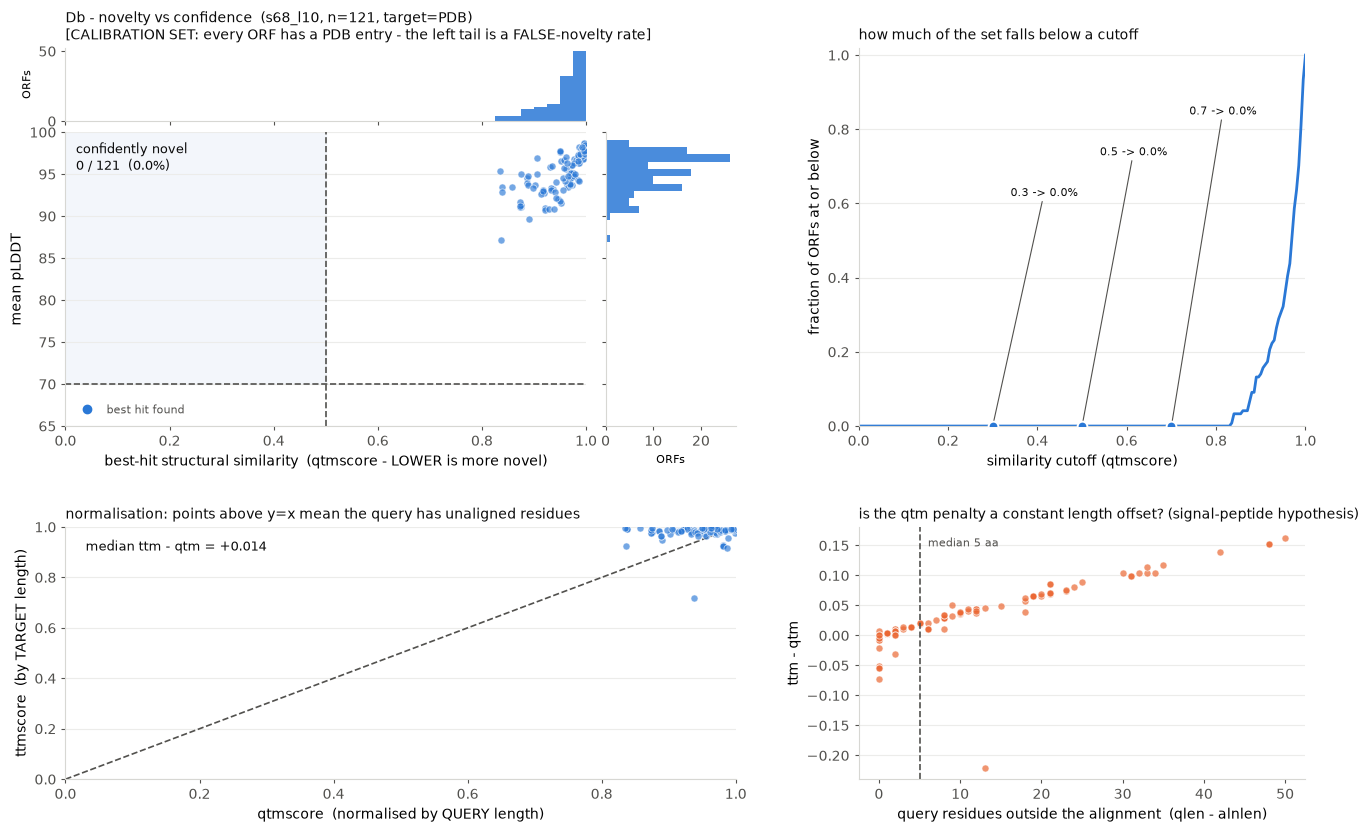

In [5]:
from matplotlib.lines import Line2D

TM_CUT, PLDDT_CUT = 0.5, 70.0     # PROVISIONAL -- 4c argues these must be calibrated, not assumed


def plot_db(d=None, label=LABEL, tm_cut=TM_CUT, plddt_cut=PLDDT_CUT, calibration=True):
    """Db: best-hit structural similarity against self-confidence.

    `calibration=True` states on the figure that this run is a KNOWN-HOMOLOG set, so its left tail is
    a FALSE-novelty rate rather than a discovery. Set it False for the real centroid run.
    """
    d = d if d is not None else load_novelty()
    sf = d["score_field"]
    tm, pl, nh = d["tm"], d["plddt"], d["no_hit"]
    ok = np.isfinite(tm) & np.isfinite(pl)
    n = int(ok.sum())
    if not n:
        print("nothing to plot -- no ORF has both a score and a confidence")
        return d

    fig = plt.figure(figsize=(16, 9.5))
    outer = fig.add_gridspec(2, 2, height_ratios=[3, 2], width_ratios=[3, 2],
                             hspace=0.32, wspace=0.22)
    # The joint panel and its marginals are ONE object, so they get their own tight subgrid --
    # separated by figure-level hspace they read as unrelated panels.
    inner = outer[0, 0].subgridspec(2, 2, height_ratios=[1, 4], width_ratios=[4, 1],
                                    hspace=0.06, wspace=0.06)
    ax = fig.add_subplot(inner[1, 0])
    axtop = fig.add_subplot(inner[0, 0], sharex=ax)
    axright = fig.add_subplot(inner[1, 1], sharey=ax)

    # y-range follows the data but always keeps the pLDDT cut visible, so the quadrant stays legible
    # even when (as on this set) every structure sits above 87.
    ylo = float(min(plddt_cut - 5, np.nanmin(pl[ok]) - 3))
    ax.axvspan(0, tm_cut, ymin=(plddt_cut - ylo) / (100 - ylo), color="#f3f6fb", zorder=0)
    ax.axvline(tm_cut, color=MUTED, ls="--", lw=1.2, zorder=2)
    ax.axhline(plddt_cut, color=MUTED, ls="--", lw=1.2, zorder=2)

    dense = n > 4000          # a scatter of 630k points is one solid blob; bin instead
    if dense:
        hb = ax.hexbin(tm[ok], pl[ok], gridsize=55, extent=(0, 1, ylo, 100),
                       cmap=SEQ_BLUE, mincnt=1, norm=LogNorm(), linewidths=0)
        cb = fig.colorbar(hb, ax=axright, pad=0.06, fraction=0.5)
        cb.set_label("ORFs (log)", color=MUTED, fontsize=8)
        cb.ax.tick_params(colors=MUTED, labelsize=8)
    else:
        ax.scatter(tm[ok & ~nh], pl[ok & ~nh], s=26, color=BLUE, alpha=.65,
                   edgecolor="white", linewidth=.6, zorder=3)
        if (ok & nh).any():
            ax.scatter(tm[ok & nh], pl[ok & nh], s=54, marker="^", color=ORANGE,
                       edgecolor="white", linewidth=.8, zorder=4)
        handles = [Line2D([], [], marker="o", ls="", color=BLUE, label="best hit found")]
        if (ok & nh).any():
            handles.append(Line2D([], [], marker="^", ls="", color=ORANGE,
                                  label=f"no hit ({int((ok & nh).sum())}) - drawn at 0"))
        ax.legend(handles=handles, frameon=False, fontsize=8, loc="lower left", labelcolor=MUTED)

    q = int((ok & (tm <= tm_cut) & (pl >= plddt_cut)).sum())
    ax.annotate(f"confidently novel\n{q} / {n}  ({100*q/n:.1f}%)", (0.02, 0.97),
                xycoords="axes fraction", va="top", fontsize=9, color=INK)
    ax.set_xlim(0, 1); ax.set_ylim(ylo, 100)
    ax.set_xlabel(f"best-hit structural similarity  ({sf} - LOWER is more novel)")
    ax.set_ylabel("mean pLDDT")
    _tidy(ax)

    axtop.hist(tm[ok], bins=np.linspace(0, 1, 41), color=BLUE, alpha=.85)
    axtop.set_ylabel("ORFs", fontsize=8); axtop.tick_params(labelbottom=False)
    _tidy(axtop); axtop.grid(False)
    axright.hist(pl[ok], bins=np.linspace(ylo, 100, 41), orientation="horizontal",
                 color=BLUE, alpha=.85)
    axright.set_xlabel("ORFs", fontsize=8); axright.tick_params(labelleft=False)
    _tidy(axright); axright.grid(False)

    title = f"Db - novelty vs confidence  ({label}, n={n:,}, target=PDB)"
    if calibration:
        title += "\n[CALIBRATION SET: every ORF has a PDB entry - the left tail is a FALSE-novelty rate]"
    axtop.set_title(title, fontsize=10, color=INK, loc="left")

    # ---- survival: fraction at or BELOW a cutoff (novelty is a LOW-similarity claim) ----------
    axs = fig.add_subplot(outer[0, 1])
    xs = np.linspace(0, 1, 201)
    axs.plot(xs, [(tm[ok] <= x).mean() for x in xs], color=BLUE, lw=2)
    # On a known-homolog set these all sit near zero, so a shared offset stacks the labels into
    # mush -- ladder them up the panel and lead back with a thin line instead.
    for i, t in enumerate((0.3, 0.5, 0.7)):
        f = (tm[ok] <= t).mean()
        axs.plot([t], [f], "o", ms=7, color=BLUE, mec="white", mew=1.4, zorder=4)
        axs.annotate(f"{t:g} -> {100*f:.1f}%", (t, f), xytext=(t + 0.04, 0.62 + 0.11 * i),
                     textcoords="data", fontsize=8, color=INK,
                     arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8, shrinkA=0, shrinkB=3))
    axs.set_ylim(0, 1.02); axs.set_xlim(0, 1)
    axs.set_xlabel(f"similarity cutoff ({sf})")
    axs.set_ylabel("fraction of ORFs at or below")
    axs.set_title("how much of the set falls below a cutoff", fontsize=10, color=INK, loc="left")
    _tidy(axs)

    # ---- which normalisation? ----------------------------------------------------------------
    axn = fig.add_subplot(outer[1, 0])
    m = ok & ~nh & np.isfinite(d["qtm"]) & np.isfinite(d["ttm"])
    axn.plot([0, 1], [0, 1], color=MUTED, ls="--", lw=1.2, zorder=1)
    axn.scatter(d["qtm"][m], d["ttm"][m], s=26, color=BLUE, alpha=.65,
                edgecolor="white", linewidth=.6, zorder=3)
    if m.any():
        axn.annotate(f"median ttm - qtm = {np.median(d['ttm'][m] - d['qtm'][m]):+.3f}",
                     (0.03, 0.95), xycoords="axes fraction", va="top", fontsize=9, color=INK)
    axn.set_xlim(0, 1); axn.set_ylim(0, 1)
    axn.set_xlabel("qtmscore  (normalised by QUERY length)")
    axn.set_ylabel("ttmscore  (by TARGET length)")
    axn.set_title("normalisation: points above y=x mean the query has unaligned residues",
                  fontsize=10, color=INK, loc="left")
    _tidy(axn)

    # ---- is that gap just a length offset? ---------------------------------------------------
    axl = fig.add_subplot(outer[1, 1])
    m2 = m & np.isfinite(d["qlen"]) & np.isfinite(d["alnlen"])
    if m2.any():
        unaligned = d["qlen"][m2] - d["alnlen"][m2]
        axl.scatter(unaligned, (d["ttm"] - d["qtm"])[m2], s=26, color=ORANGE, alpha=.7,
                    edgecolor="white", linewidth=.6)
        med = float(np.median(unaligned))
        axl.axvline(med, color=MUTED, ls="--", lw=1.2)
        axl.annotate(f"median {med:.0f} aa", (med, axl.get_ylim()[1]), textcoords="offset points",
                     xytext=(6, -14), fontsize=8, color=MUTED)
        axl.set_xlabel("query residues outside the alignment  (qlen - alnlen)")
        axl.set_ylabel("ttm - qtm")
    axl.set_title("is the qtm penalty a constant length offset? (signal-peptide hypothesis)",
                  fontsize=10, color=INK, loc="left")
    _tidy(axl)

    plt.show()
    return d


nov = plot_db(nov)

### 4c. How to read it — and the one decision still open

**This run cannot produce a novelty result, and that is the point.** The 121 stand-in ORFs were
selected in 6a *because they have a PDB entry*. Every one of them is a known homolog, so anything
appearing in the "confidently novel" corner is a **false positive**, and the left tail of panel 1 is
a measured **false-novelty rate**, not a discovery. That makes this run worth more than a novelty
number would be: it is the only calibration set available, and it is what a threshold can be
justified against.

#### The normalisation question

TM-score is asymmetric, and the two normalisations answer different questions:

| | question it answers | fails when |
|---|---|---|
| `qtmscore` (by query length) | "how much of **my ORF** is explained by a known structure?" | the ORF carries residues no crystal structure would ever contain — every ORF is penalised by a near-constant, shifting the whole distribution **toward false novelty** |
| `ttmscore` (by target length) | "is there a known structure my ORF **contains**?" | a small PDB domain matching a fragment of a long ORF scores ≈ 1, shifting **against** novelty |

The `--check-env` probe already showed this is not hypothetical: ORF 3772973 hit `8ait` at
**qtm 0.838 / ttm 0.990**, lddt 0.94, E-value 1e-54 — unambiguously the same protein, with a 0.15 gap
opened purely by normalisation. The likely cause is structural rather than biological: **we fold full
ORFs** (`petadex.catalytic_orfs.v1.1.fa`, per 6a) while PDB holds the *mature, cleaved* construct, so
signal and pro-peptides are unalignable by construction. See `resources/260503_issue18_signalsequences/`.

**Panel 4 is the test.** If `ttm − qtm` rises linearly with the number of unaligned query residues and
those cluster around a signal-peptide-sized value, the gap is an artefact and `qtmscore` is
systematically over-reporting novelty. If the unaligned counts are scattered with no relationship,
the gap is real structural difference and `qtmscore` is the honest metric.

Three ways to resolve it, in decreasing order of preference:

1. **trim to the mature sequence before folding** — cleanest, but it re-folds the set and touches 6a;
2. **report `qtmscore` with the threshold calibrated on this set** — cheap, defensible, and what the
   panels above are set up for: pick the cutoff *below* where the known homologs land;
3. **report both** and treat their disagreement as the uncertainty band.

#### The other thing that must happen before a number is published

`--exhaustive` on the no-hit set. Foldseek's prefilter is a heuristic, so "no hit" and "novel" are
indistinguishable in the ledger, and only one of them is a result:

```bash
python3 foldseek_novelty.py --run <same> --target ~/db/pdb --out nov_exhaustive \
    --exhaustive --limit 50
```

#### Conclusions

*(To be written once the full centroid fold exists, and once panel 4 has settled the normalisation.)*

What this pass **does** establish: the four-stage pipeline runs end to end on real data; no-hit ORFs
survive into the figure instead of being silently dropped; the confidence join is free; and the same
two cells produce the real figure at 630k, switching to a binned density automatically. What it
explicitly does **not** establish is any statement about novelty — for that, `S3_RUN` has to point at
the centroid set, and `calibration=False` should then be passed to `plot_db()`.